In [1]:
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd


from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose

Importing plotly failed. Interactive plots will not work.


In [2]:
df = pd.read_excel("C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/PROJECT/RoadTrafficCollisions/df_ts_1.xlsx")
df.drop(columns = 'Unnamed: 0', inplace =True)
df.head(3)


,Date,Tmax °C,Tmin °C,Daily Tmean °C,Daily range degC,Grass min °C,Air frost 0/1,Ground frost 0/1,Max ≥ 25.0°C,Max ≥ 30.0°C,Min ≥ 15.0 °C,Max < 0 °C,Rainfall mm raw incl traces,Rainfall mm 1 dpl no traces,Rain day (0.2 mm or more),Wet day (1.0 mm or more),Sunshine duration h,Nil sunshine,12 h sunshine,Incident_Count
0,2015-01-01,13.5,2.6,8.1,10.9,0,0,0.0,0,0,0,0,0.9,0.9,1,0,0.0,1,0,3
1,2015-01-02,9.2,5.9,7.6,3.3,0.3,0,0.0,0,0,0,0,10.7,10.7,1,1,6.5,0,0,0
2,2015-01-03,4.9,3.0,4.0,1.9,-4.5,0,1.0,0,0,0,0,3.7,3.7,1,1,0.0,1,0,0


### set timescale for that of 2015-01-01 to 2024-12-31 inclusive

In [3]:
#df = df[df['Date']<'2025-01-01']
df['Date'].min(),df['Date'].max()

(Timestamp('2015-01-01 00:00:00'), Timestamp('2025-12-30 00:00:00'))

### Exploratory analysis

In [4]:
df['Incident_Count'].describe()

count    4017.000000
mean        1.183968
std         1.149555
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         8.000000
Name: Incident_Count, dtype: float64

### Plot the Incident_Count over time

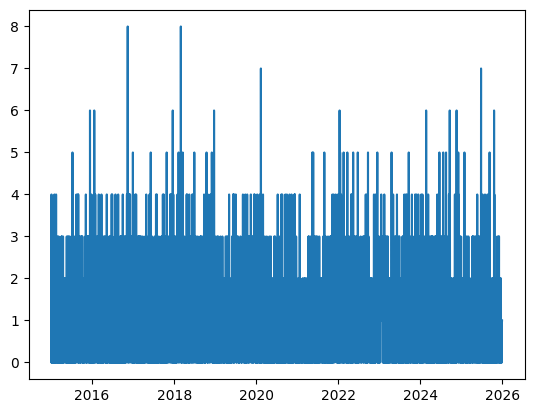

<Figure size 4000x2000 with 0 Axes>

In [5]:
plt.plot(df['Date'], df['Incident_Count'])
plt.figure(figsize=(40, 20))
plt.show()

In [6]:
df = pd.read_excel("C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/PROJECT/RoadTrafficCollisions/df_ts_1.xlsx", parse_dates = ["Date"], index_col = 'Date')
df.drop(columns = 'Unnamed: 0', inplace =True)
df.head(3)

,Tmax °C,Tmin °C,Daily Tmean °C,Daily range degC,Grass min °C,Air frost 0/1,Ground frost 0/1,Max ≥ 25.0°C,Max ≥ 30.0°C,Min ≥ 15.0 °C,Max < 0 °C,Rainfall mm raw incl traces,Rainfall mm 1 dpl no traces,Rain day (0.2 mm or more),Wet day (1.0 mm or more),Sunshine duration h,Nil sunshine,12 h sunshine,Incident_Count
Date,,,,,,,,,,,,,,,,,,,
2015-01-01,13.5,2.6,8.1,10.9,0,0,0.0,0,0,0,0,0.9,0.9,1,0,0.0,1,0,3
2015-01-02,9.2,5.9,7.6,3.3,0.3,0,0.0,0,0,0,0,10.7,10.7,1,1,6.5,0,0,0
2015-01-03,4.9,3.0,4.0,1.9,-4.5,0,1.0,0,0,0,0,3.7,3.7,1,1,0.0,1,0,0


In [7]:
def ts_decompose(y, model ='additive'):
    result = seasonal_decompose(y, model = model)
    fig, axes = plt.subplots(4,1, sharex =False, sharey=False)
    fig.set_figheight(10)
    fig.set_figwidth(15)

    axes[0].set_title("Decomposition for "+model+ "model")
    axes[0].plot(y, "k", label = 'Original ' + model + 'model')
    axes[0].legend(loc= 'upper left')

    
    axes[1].plot(result.trend,  label ='Trend')
    axes[1].legend(loc= 'upper left')

    axes[2].plot(result.seasonal,"g", label ='Seasonality')
    axes[2].legend(loc= 'upper left')

    axes[3].plot(result.resid,"g", label ='Residuals')
    axes[3].legend(loc= 'upper left')
    
    plt.show(block = True)
    return

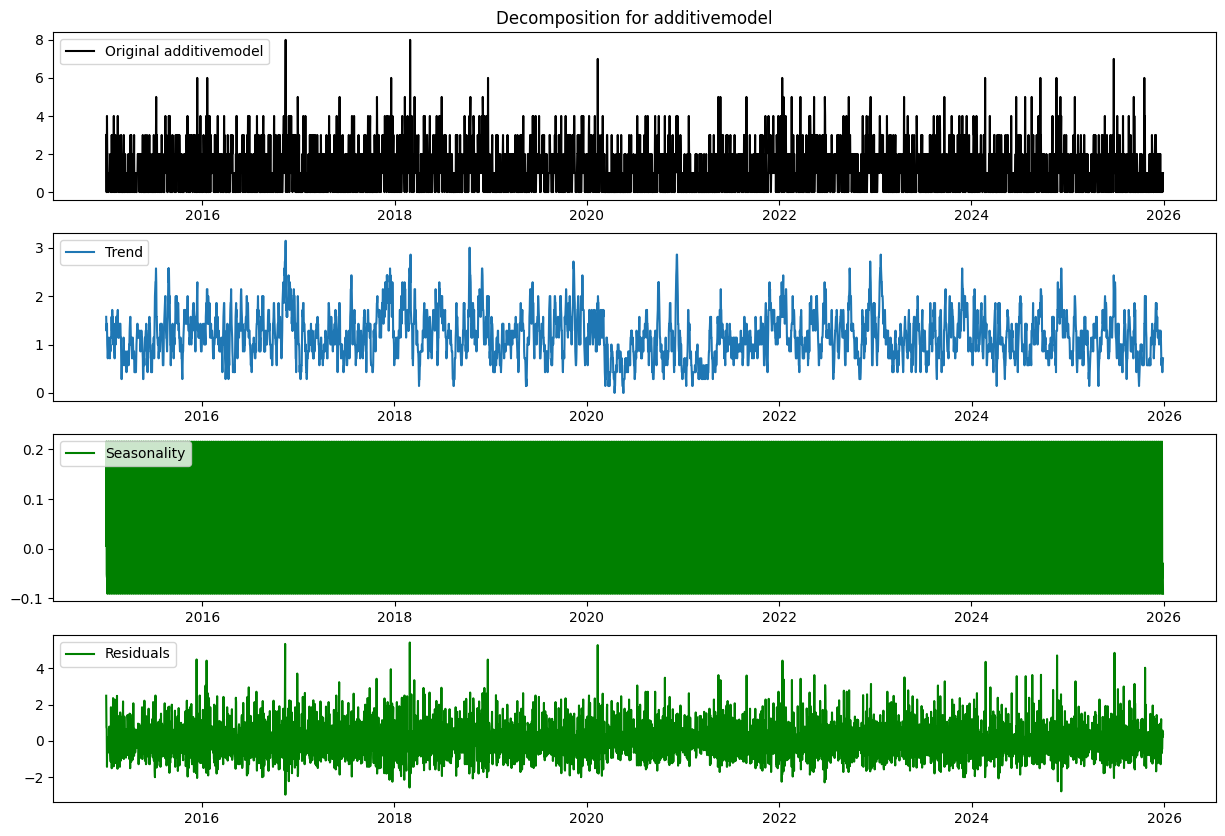

In [8]:
ts_decompose(df['Incident_Count'])

### Which does not indicate evry much at all
### Try downsampling from days to weeks

In [9]:
df_weekly = df['Incident_Count'].resample("W").sum()
df_monthly  = df['Incident_Count'].resample('ME').sum()

C:\Users\pw347789\AppData\Local\Temp\ipykernel_20916\902179621.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


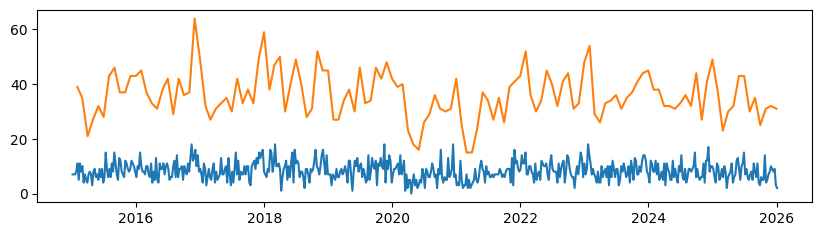

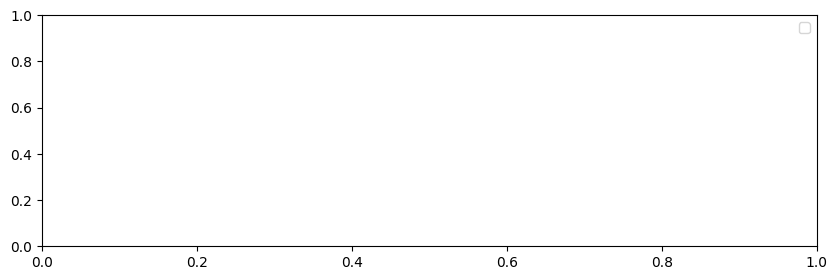

In [75]:
#plt.plot(df, label = "df")
plt.figure(figsize = (10, 2.5))
plt.plot(df_weekly,  label = "Weekly")
plt.plot(df_monthly,  label = "Monthly")
plt.figure(figsize = (10,3))
plt.legend()
plt.show()

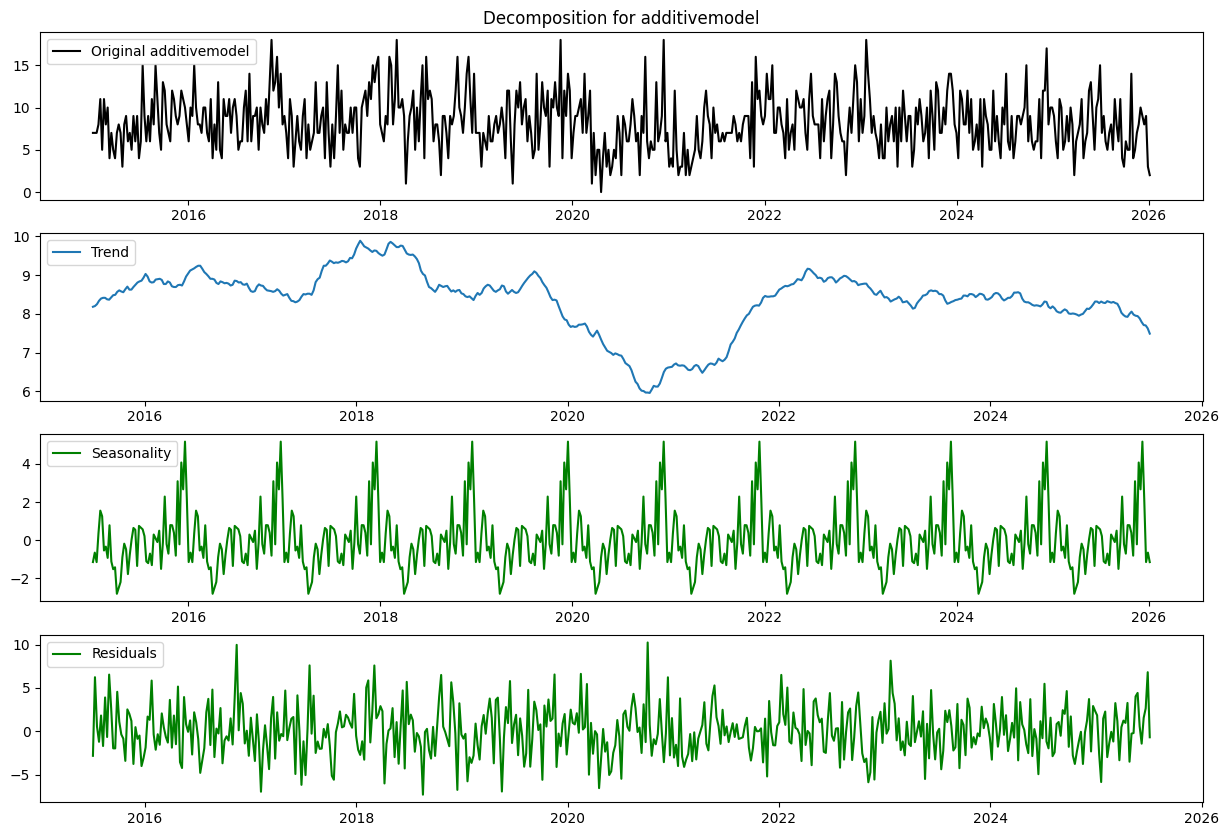

In [76]:
ts_decompose(df_weekly)
#ts_decompose(df_monthly)

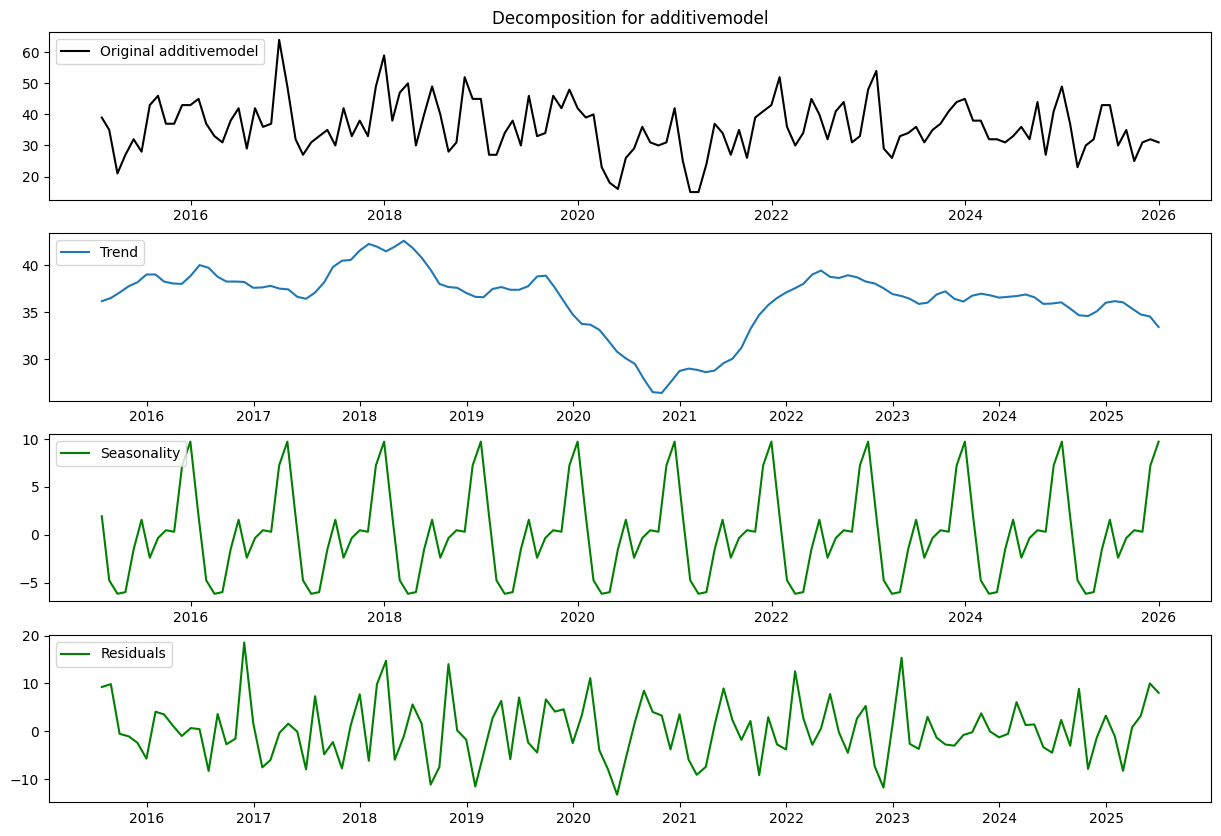

In [77]:
ts_decompose(df_monthly)

### Smoothing

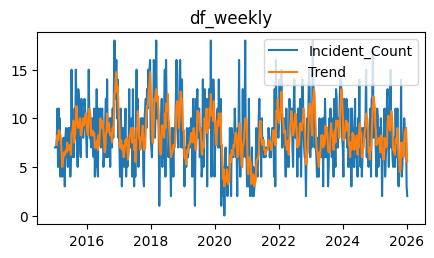

In [79]:
plt.figure(figsize = (5, 2.5))
plt.title("df_weekly")
plt.plot(df_weekly,  label = "Incident_Count")
rolling_mean = df_weekly.rolling(window = 4).mean()
plt.plot(rolling_mean, label = 'Trend')
plt.legend()

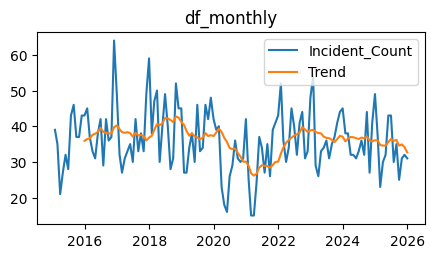

In [80]:
plt.figure(figsize = (5, 2.5))
plt.title("df_monthly")
plt.plot(df_monthly,  label = "Incident_Count")
rolling_mean = df_monthly.rolling(window = 12).mean()
plt.plot(rolling_mean, label = 'Trend')
plt.legend()

## Exponential Moving Averages

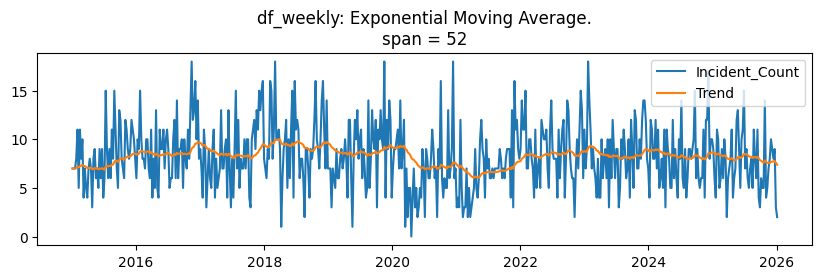

In [86]:
span = 52
plt.figure(figsize = (10, 2.5))
plt.title(f"df_weekly: Exponential Moving Average.\nspan = {span}")
plt.plot(df_weekly,  label = "Incident_Count")
exp_rolling_mean = df_weekly.ewm(span = span, adjust = False).mean()
plt.plot(exp_rolling_mean, label = 'Trend')
plt.legend()

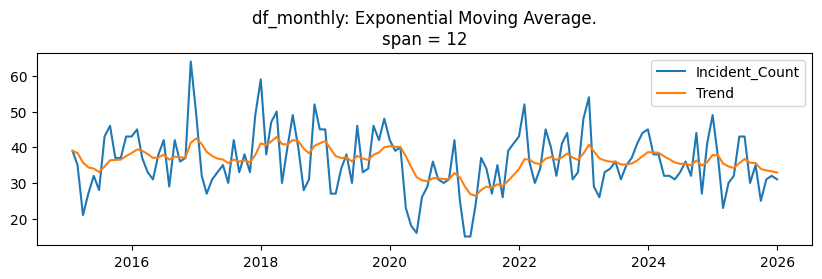

In [87]:
span = 12
plt.figure(figsize = (10, 2.5))
plt.plot(df_monthly,  label = "Incident_Count")
plt.title(f"df_monthly: Exponential Moving Average.\nspan = {span}")
exp_rolling_mean = df_monthly.ewm(span = span, adjust = False).mean()
plt.plot(exp_rolling_mean, label = 'Trend')
plt.legend()

### Differencing:

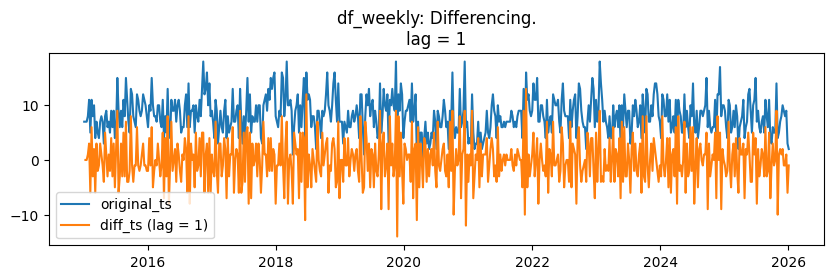

In [90]:
lag = 1
plt.figure(figsize = (10, 2.5))
plt.title(f"df_weekly: Differencing.\nlag = {lag}")
plt.plot(df_weekly, label = 'original_ts')
plt.plot(df_weekly.diff(lag), label = f'diff_ts (lag = {lag})')
plt.legend()

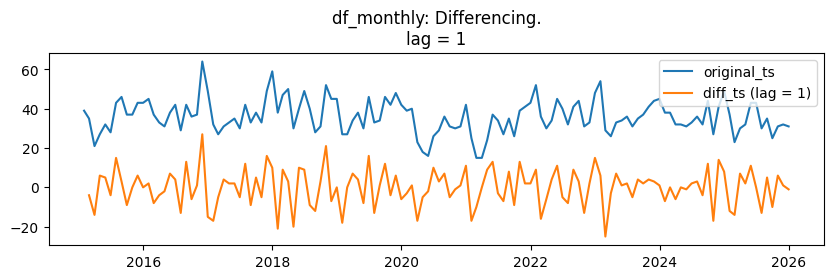

In [91]:
lag = 1
plt.figure(figsize = (10, 2.5))
plt.title(f"df_monthly: Differencing.\nlag = {lag}")
plt.plot(df_monthly, label = 'original_ts')
plt.plot(df_monthly.diff(lag), label = f'diff_ts (lag = {lag})')
plt.legend()

## Incident Counts in a given month:

In [92]:
jan_start = pd.Timestamp(2015, 1, 1)
jan_end   = pd.Timestamp(2016, 1, 31)

df_weekly_jan = df_weekly[jan_start: jan_end].sum()

In [93]:
print(df_weekly_jan)

476


## STATIONARITY:

In [94]:
from statsmodels.tsa.stattools import adfuller

In [95]:
def testStationarity(x, alpha = 0.05):
    results = adfuller(x)
    pval = results[1]
    if pval < alpha:
        return "Reject Null: TS == stationary"
    else:
        return "Accept Null: TS =! stationary"

In [96]:
testStationarity(df_weekly)

'Reject Null: TS == stationary'

In [97]:
testStationarity(df_monthly)

'Reject Null: TS == stationary'

# SEASONALITY

## To aid decisins regarding SEASONALITY

### Autocorrelation:

Autocorrelation Function (ACF) & Partial ACF (PACF) Plots: 

Look for repeating spikes or significant positive correlations at seasonal lags (e.g., lag 12 for monthly data, lag 4 for quarterly data).

In [99]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

## WEEKLY dataframe

<Figure size 200x200 with 0 Axes>

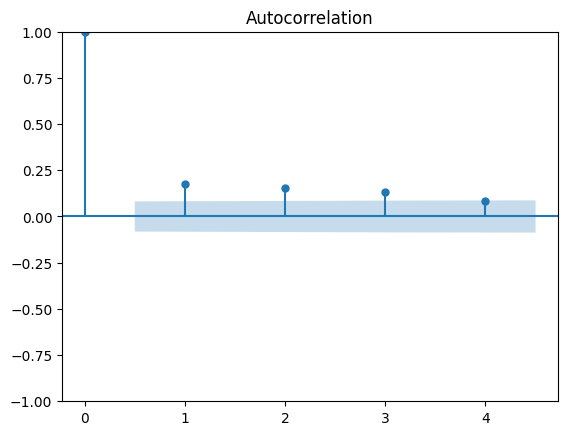

In [105]:
plt.figure(figsize=(2,2))
plot_acf(df_weekly, lags = 4)
plt.show()

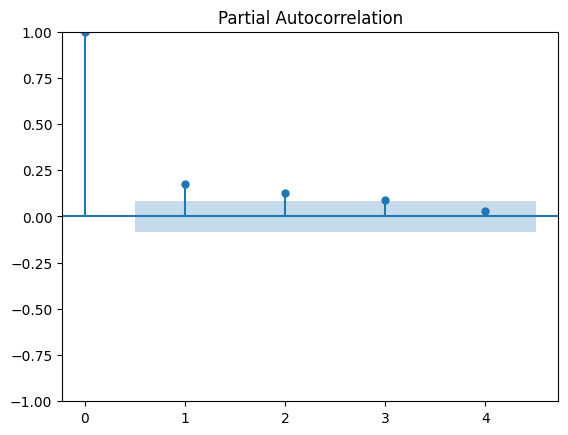

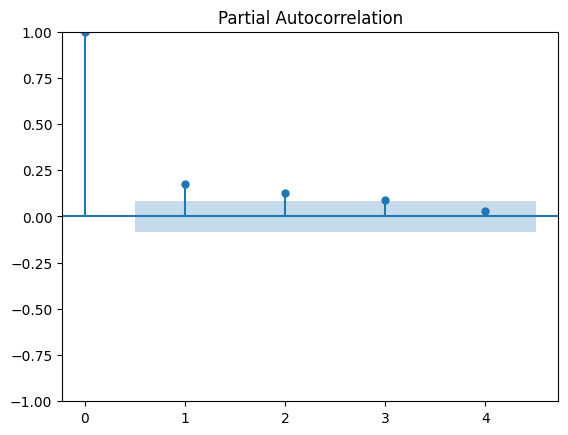

In [106]:
plot_pacf(df_weekly, lags = 4)

## MONTHLY dataframe

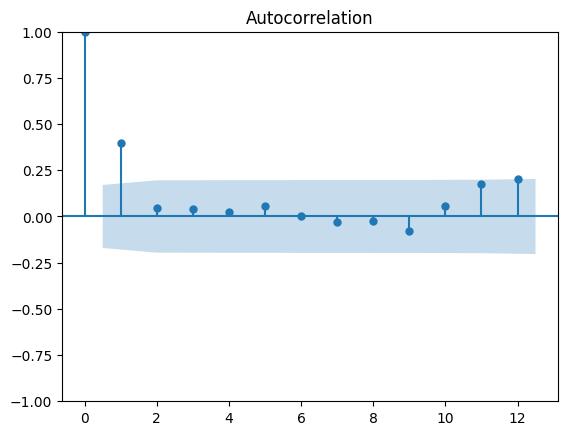

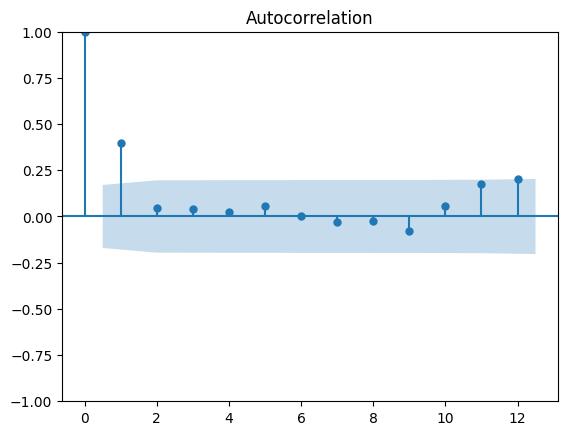

In [107]:
plot_acf(df_monthly, lags = 12)

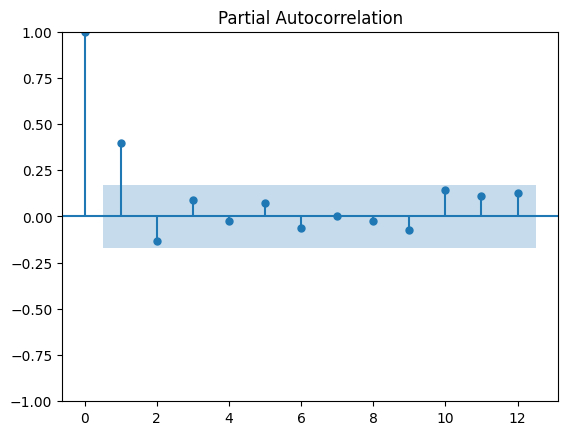

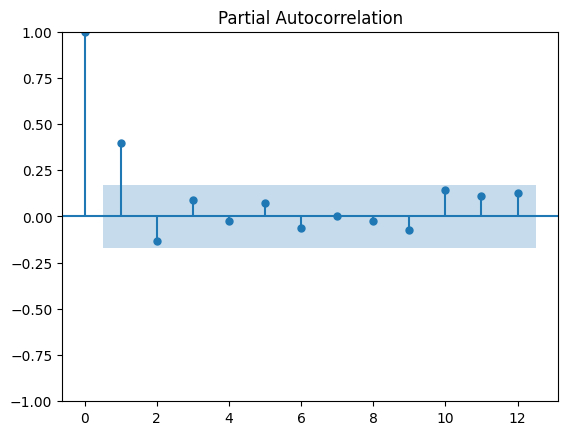

In [108]:
plot_pacf(df_monthly, lags = 12)

#### add test metrics
#### from Time series Testing: 
##### Evaluating and Testing Forecast Models

In [109]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose


import re
from datetime import datetime
from statsmodels.api import tsa
from statsmodels.tsa.ar_model import ar_select_order
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf

In [111]:
df.head(2)

,Tmax °C,Tmin °C,Daily Tmean °C,Daily range degC,Grass min °C,Air frost 0/1,Ground frost 0/1,Max ≥ 25.0°C,Max ≥ 30.0°C,Min ≥ 15.0 °C,Max < 0 °C,Rainfall mm raw incl traces,Rainfall mm 1 dpl no traces,Rain day (0.2 mm or more),Wet day (1.0 mm or more),Sunshine duration h,Nil sunshine,12 h sunshine,Incident_Count
Date,,,,,,,,,,,,,,,,,,,
2015-01-01,13.5,2.6,8.1,10.9,0,0,0.0,0,0,0,0,0.9,0.9,1,0,0.0,1,0,3
2015-01-02,9.2,5.9,7.6,3.3,0.3,0,0.0,0,0,0,0,10.7,10.7,1,1,6.5,0,0,0


In [112]:
df_weekly

2015-01-04     7
2015-01-11     7
2015-01-18     7
2015-01-25     8
2015-02-01    11
              ..
2025-12-07     9
2025-12-14     8
2025-12-21     9
2025-12-28     3
2026-01-04     2
Freq: W-SUN, Name: Incident_Count, Length: 575, dtype: int64

In [159]:

#df_weekly = df_weekly['Incident_Count'].resample("W").sum()

df_weekly.dropna(inplace = True)
#df_weekly = df_weekly.loc[:,["Date", "Incident_Count"]]
df_weekly.dropna(inplace = True)
# Convert the data to have datetime indices with frequencey of month start
#df_weekly.set_index("Date", inplace=True)
#df_test.index = pd.to_datetime(df.index, format="%Y-%m-%d")


#time_series = df_weekly#.diff(1).dropna()

time_series = df_weekly
time_series = df_monthly
time_series.head()



Date
2015-01-31    39
2015-02-28    35
2015-03-31    21
2015-04-30    27
2015-05-31    32
Freq: ME, Name: Incident_Count, dtype: int64

### Testing for Forecasting models:
##### involving residual diagnostics, train/tets splits, cross validation

Residuals
Residuals in general refer to what is 'left over' and so residuals of a model are given by the difference between the raw observations (i.e. our data) and the corresponding fitted values.

𝑒𝑡=𝑦𝑡−𝑦̂ 𝑡
 

We have seen previously that when tuning and selecting a time series model, we can use the mean absolute error as a metric. We will now look at how else you can use the residuals.

Analysing the residuals
The residuals allow us to confirm if a time series model has captured the data adequately by using the following checks:

A good forecasting method will have:

1) Uncorrelated residuals
IF there is a strong relationship between residuals then more information can be used from them to compute forecasts.

2) Zero mean of the residuals, as otherwise the forecasts are biased.

This is not to say that if these conditions are satisfied then we can't improve our model, however it is an important step to checking our model choice.

Notes
Residuals are a concept which are commonly used when fitting and evaluating regression models, with the simplest example being linear regression. Considering the residuals, or errors, can also apply to time series and be a very useful method for checking if a model has captured the data well.

In particular, each observation in a time series can be forecast using all previous observations. These fitted values are not true forecasts because the parameters are estimated using all available data, however they allow us to compute the residuals and assess our model.

The mean absolute error of the residuals is one choice of model evaluation, however we can also check that these residuals have features of a good forecasting model and inform us of how to make changes.

The main features to check for are that the residuals are uncorrelated and have zero mean. We will now explore how to test this.

Extra note:

In the case that we have non-zero mean residuals, we can simply add the mean of the residuals to our estimates to unbias the forecasts. Handling correlated residuals is harder to do but further information on this can be found in Chapter 9 of the book given here: https://otexts.com/fpp2/residuals.html.

### Fitting an AR model

#### We can fit an AR model to our revenue data using lags selected to optimise the AIC.

from Google AI:
Fitting an Autoregressive (AR) model to revenue data using lags selected by optimizing the Akaike Information Criterion (AIC) is a robust approach to time series forecasting. The AIC balances model goodness-of-fit against complexity (number of lags), preventing overfitting by penalizing models with excessive parameters.¶

In [160]:
from statsmodels.tsa.ar_model import ar_select_order

Optimal p =  2


Text(0.5, 1.0, 'tsa.AutoReg with Optlag = 2')

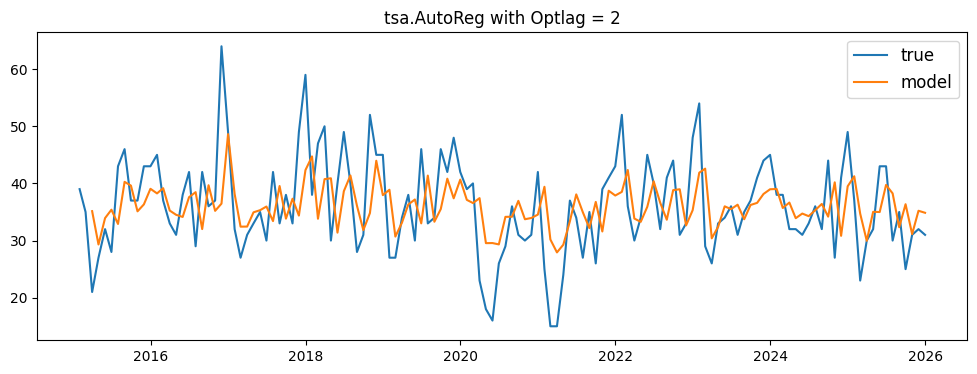

In [161]:
mod = ar_select_order(time_series, maxlag = 12, ic = "aic")
optlag = max(mod.ar_lags)
print("Optimal p = ", optlag)


ar = tsa.AutoReg(time_series, lags = optlag)
ar_result = ar.fit()
prediction = ar_result.predict(start = optlag)

plt.figure(figsize=(12, 4))
plt.plot(time_series,  label="true")
plt.plot(prediction,  label="model")
plt.legend(fontsize=12)
plt.title(f'tsa.AutoReg with Optlag = {optlag}')


### Asssesing Residual Diagnostics

In [162]:
fit_residuals = time_series[optlag:].values.flatten() - prediction

The mean Residual value:  1.8638082530322628e-14


Text(0, 0.5, 'Residual 10^e-14')

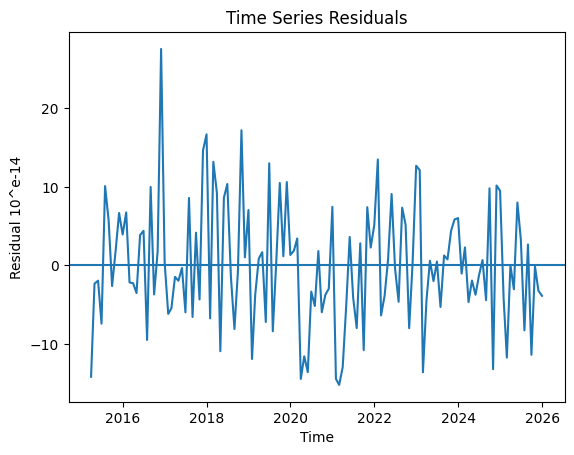

In [163]:
print("The mean Residual value: ", np.mean(fit_residuals))
plt.plot(fit_residuals)
plt.title("Time Series Residuals")
plt.xlabel('Time')
plt.axhline(y=np.mean(fit_residuals))
plt.ylabel('Residual 10^e-14')

### the time series is good if there is no trend associated with the residuals:
#### Can the adfuller test confirm this?

In [164]:
testStationarity(fit_residuals, alpha = 0.05)

'Reject Null: TS == stationary'

### And a check for uncorrelated residuals

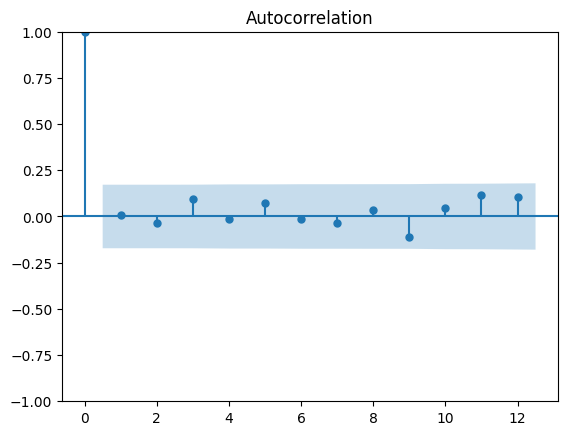

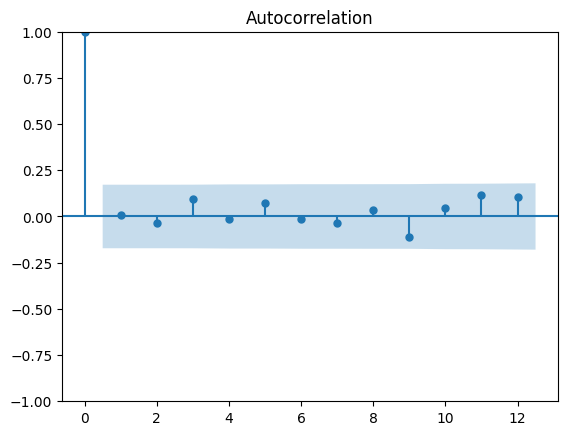

In [165]:
plot_acf(fit_residuals, lags = 12)

Notes

The autocorrelation function checks for internal correlation of a series with lagged versions of itself. In order for the residuals to be uncorrelated we need to see that there is no lag for which we have significant correlation.


The plot_acf function plots a blue 'corridor' which indicates the region of non significant correlation. As all our values are within this blue shaded region for all lags, we can say that our lags are uncorrelated.


Extra: If the variance of the residuals is not constant, we say that heteroscedasticy exists.

### Residual Variance:
#### Is the variance of residuals constant... do they fit a normal distribution?

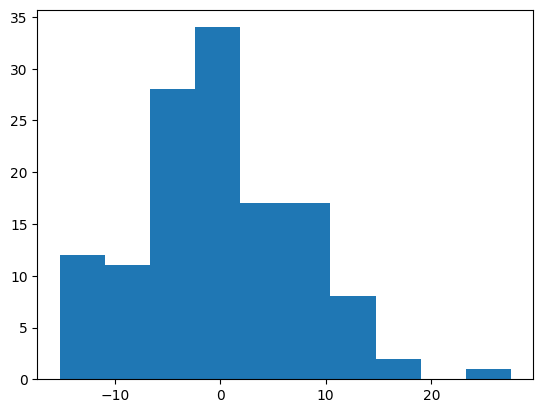

In [166]:
plt.hist(fit_residuals)
plt.show()

## by the Shapiro test for normality

In [167]:
from scipy.stats import shapiro
test = shapiro(fit_residuals)


print("The p value is ", test.pvalue, "> 0.05")
print(f"Which denotes {test.pvalue *100:.1f}% of this data is normal")

The p value is  0.13377771693554497 > 0.05
Which denotes 13.4% of this data is normal


### Conclusion.
#### The weekly based time series is NOT normally distributed enough.
#### Which will involve some sort of transformation, such as log_transform and then refit ARIMA
#### The MONTHLY based time series IS normally distributed enough.
#### So we continue using the monthly dtatset

In [168]:
df_monthly.shape

(132,)

## FORECASTING


Until now we have tuned the model to fit the time series and explore ways to assess the fit of a time series. This allows us to find a description of the data, but doesn't give a forecast.

It is important to evaluate forecast accuracy using genuine forecasts and so we have to use data that was not used to form the model in order to generate a prediction.

So as with other ML models, we split our time series data into training and test, with the test set being in the region of 15-30% of the total sample, depending on the size of the sample and distance into the future which you would like to predict.

Caveat for Time Series Testing
Testing a standard prediction model can be done in many ways. Usually we don't need to worry about ordering over observations so we can just go ahead and divide or sample our data.

However, with time-series data we need to account for the chronological ordering.

To do this, we must make sure that we only use past observations when making predictions. This is also important to be realistic in a production setting.

In [170]:
int(time_series.shape[0]*0.3)  

39

Out of sample MAE = 5.780


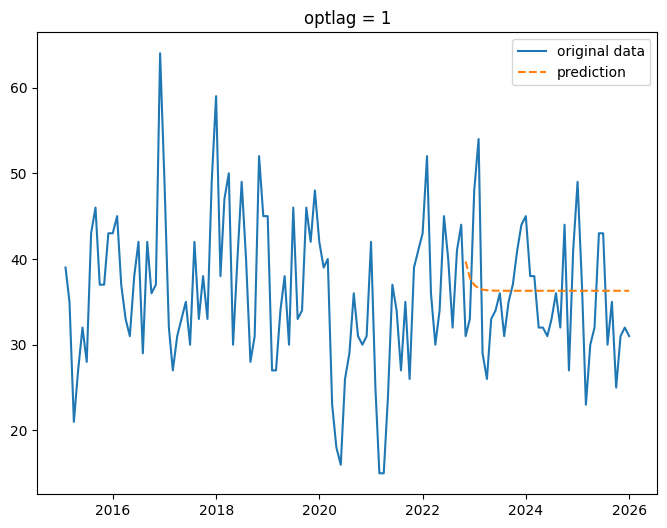

In [171]:
# divide data into training and testing:
split_value = int(df_monthly.shape[0]*0.3)
train = time_series[:-split_value]
test  = time_series[-split_value:]

# choose the optimal lag using AIC (this is a model selection criterion) and the training data
mod = ar_select_order(train, maxlag=12, ic="aic")
optlag = min(mod.ar_lags)

# fit our AR model using the tsa module
ar = tsa.AutoReg(train, lags=optlag)

# now we fit our model
arfit = ar.fit()

# we make predictions on unseen data:
prediction = arfit.predict(end=len(time_series) - 1)[-len(test) :]
# preiction on unseen data:
prediction = arfit.predict(end = len(time_series)-1)[-len(test):]

plt.figure(figsize=(8,6))
plt.plot(time_series, label = 'original data')
plt.plot(prediction, '--', label = 'prediction'   )
plt.title(f'optlag = {optlag}')

plt.legend(fontsize = 10)
print("Out of sample MAE = {0:.3f}".format(mean_absolute_error(test, prediction)))

C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Out of sample MAE = 5.276


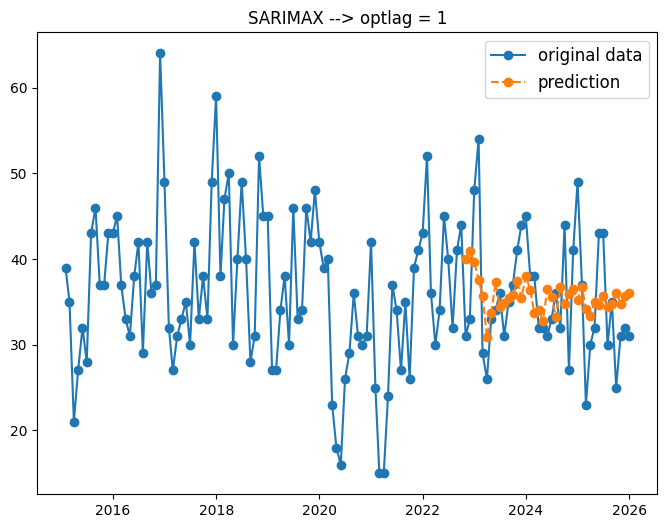

In [172]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# divide data into training and testing:
train = time_series[:-split_value]
test = time_series[-split_value:]

mod = SARIMAX(
    train,
    trend="c",
    order=(3, 0, 3),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = mod.fit()

# we make predictions on unseen data:
prediction = sarima_fit.predict(end=len(time_series) - 1)[-len(test) :]


# produce some figures:
plt.figure(figsize=(8, 6))
plt.plot(time_series, "-o", label="original data")
plt.plot(prediction, "--o", label="prediction")

plt.legend(fontsize=12)
plt.title(f'SARIMAX --> optlag = {optlag}')

print("Out of sample MAE = {0:.3f}".format(mean_absolute_error(test, prediction)))



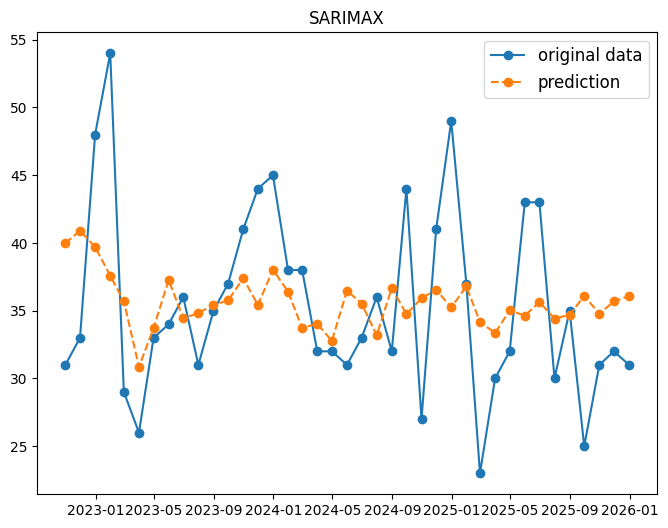

In [173]:
plt.figure(figsize=(8, 6))
plt.plot(test, "-o", label="original data")
plt.plot(prediction, "--o", label="prediction")
plt.title("SARIMAX")
plt.legend(fontsize=12)
plt.show()

In [174]:
import re
import pandas as pd
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.api import tsa
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.ar_model import ar_select_order
from statsmodels.graphics.tsaplots import plot_acf

%matplotlib inline

## We will try WEEKLY again

In [175]:
time_series = df_weekly
#time_series = df_monthly
time_series.head()
len(time_series)

575

In [176]:
# For our model building later, we attach a data frequency to the times. This is not essential but avoids warnings
time_series.index = pd.DatetimeIndex(
    time_series.index.values,
    freq=time_series.index.inferred_freq
)

len(time_series)

575

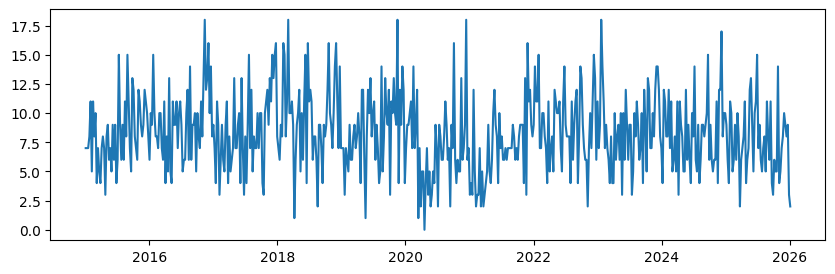

In [177]:
plt.figure(figsize=(10,3))
plt.plot(time_series, label = 'Orignal data')
plt.show()

3) Fit the data

Task:

1) Using ar_select_order() select the optimal AR parameter according to the AIC.

2) Then fit the time series model using tsa.AutoReg() and the optimal lag found

3) Form a prediction starting at the optimal lag value. Hint: use the parameter start.

4) Plot the resulting prediction and original time series

Optimal p = 5


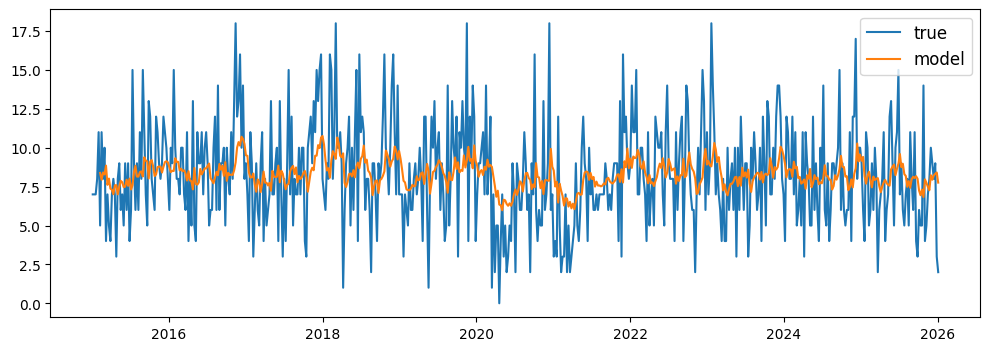

In [178]:
# Your code here...
mod = ar_select_order(time_series, maxlag=10, ic="aic")
optlag = max(mod.ar_lags)
print('Optimal p =', optlag)

ar = tsa.AutoReg(time_series, lags=optlag)
ar_result = ar.fit()
prediction = ar_result.predict(start=optlag)

plt.figure(figsize=(12, 4))
plt.plot(time_series, label='true')
plt.plot(prediction, label='model')
plt.legend(fontsize=12);


Residual diagnostics


By using time_series[optlag:].value.flatten() as the original time series (this should align with your prediction), define the residuals from the AR model fit.

Plot these residuals and the ACF in order to assess if this model is adequte.

Recall: We want the residuals to have zero mean and be uncorrelated

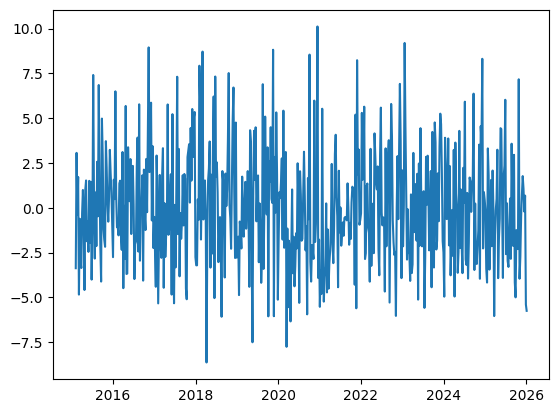

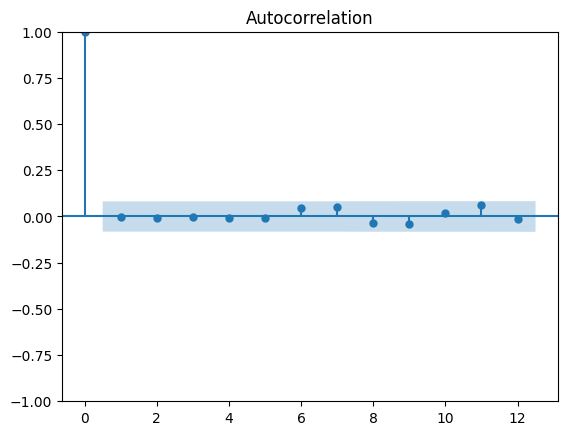

In [179]:
# Form the residuals
fit_residuals = time_series[optlag:].values.flatten() - prediction

# Plot the residuals
plt.plot(fit_residuals)
plt.show()

# Plot the acf 
plot_acf(fit_residuals, lags=12)
plt.show()

4) Forecasting

Note: forecasting with time series data is tricky and usually basic methods do not really provide very good results (especially on realistic data). ARMA models are nice because they are simple but do not expect fantastic performances. (On the other hand, predicting the future is hard! -- who would have thought).

Separate the time series into a training set and a test set formed of the last 40 points.
To do this you can index time_series with [:-40] and [-40:]
Fit an AR model on the training data and try to find the optimal lag using the BIC criterion, an alternative to the AIC which also accounts for the sample size.
Use the ar_select_order function on your training data and use the parameters maxlag and ic
Then use the AutoReg function with your training data and use the lags parameter to specify the optimal lags found
Predict and show the prediction on the original time series. Did it do a good job?
For this step you will find the .fit() and .predict() functions useful
Note that for the prediction, we want to store the indices [-len(test):] as these are form our forecast
compute the MAE
The function mean_absolute_error will let you do this

In [181]:
split_value_weekly = int(df_weekly.shape[0]*0.3)  
split_value_weekly

172

3
Out of sample MAE = 2.584


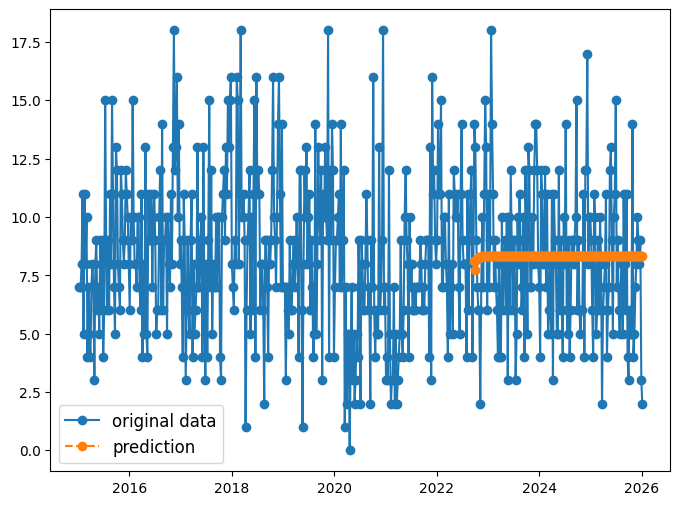

In [187]:
# divide data into training and testing:
train = df_weekly[:-split_value_weekly]
test = df_weekly[-split_value_weekly:]

# choose the optimal lag using AIC (this is a model selection criterion)
mod = ar_select_order(train, maxlag=10, ic="bic")
optlag = max(mod.ar_lags)
print(optlag)

# fit our AR model using the tsa module! 
ar = tsa.AutoReg(train, lags=optlag)

# now we fit our model with the chosen optimal lag:
arfit = ar.fit()

# we make predictions on unseen data:
prediction = arfit.predict(end=df_weekly.index[-1])[-len(test):]

# produce some figures:
plt.figure(figsize=(8, 6))
plt.plot(df_weekly, '-o', label="original data")
plt.plot(prediction, '--o', label='prediction')

plt.legend(fontsize=12)

print('Out of sample MAE = {0:.3f}'.format(mean_absolute_error(test, prediction)))

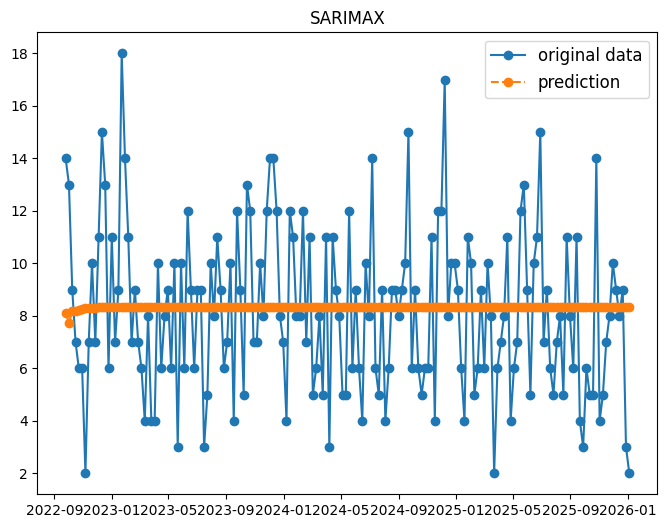

In [188]:
plt.figure(figsize=(8, 6))
plt.plot(test, "-o", label="original data")
plt.plot(prediction, "--o", label="prediction")
plt.title("SARIMAX")
plt.legend(fontsize=12)
plt.show()

Repeat for an ARMA process, using arma_order_select_ic to find the optimal parameters. How does the MAE compare to the AR process?

Note: in order to run an ARMA model using statsmodels, you can use tsa.ARIMA and set the d in the order as 0.

C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARMA(p,q) = (np.int64(1), np.int64(1)) is the best.
Out of sample MAE = 2.578


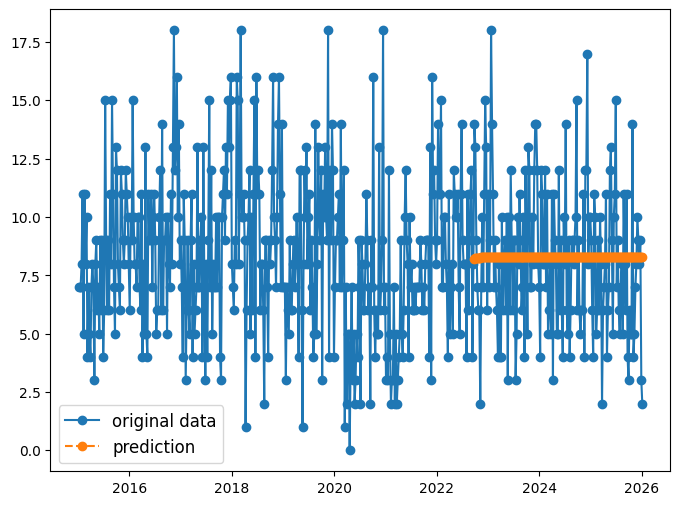

In [189]:
# divide data into training and testing:
train = df_weekly[:-split_value_weekly]
test = df_weekly[-split_value_weekly:]

# fit our ARMA model using the tsa module! 
param_choice = tsa.arma_order_select_ic(train, max_ar=2, max_ma=2, ic='bic', trend='c')
print('ARMA(p,q) =',param_choice['bic_min_order'],'is the best.')

arma = tsa.ARIMA(
    train,
    order=(param_choice['bic_min_order'][0], 0, param_choice['bic_min_order'][1])
)
arma_fit = arma.fit()

# we make predictions on unseen data:
prediction = arma_fit.predict(end=df_weekly.index[-1])[-len(test):]

# produce some figures:
plt.figure(figsize=(8, 6))
plt.plot(time_series, '-o', label="original data")
plt.plot(prediction, '--o', label='prediction')

plt.legend(fontsize=12)

print('Out of sample MAE = {0:.3f}'.format(mean_absolute_error(test, prediction)))


C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Out of sample MAE = 2.586


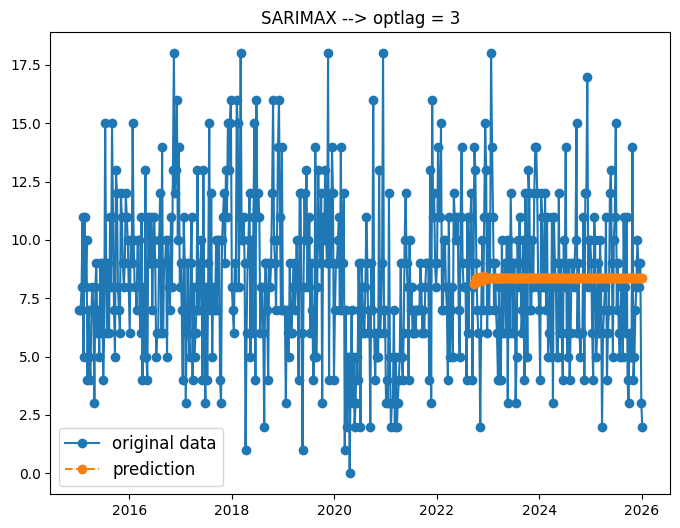

In [190]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# divide data into training and testing:
train = df_weekly[:-split_value_weekly]
test = df_weekly[-split_value_weekly:]

mod = SARIMAX(
    train,
    trend="c",
    order=(3, 0, 3),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = mod.fit()

# we make predictions on unseen data:
prediction = sarima_fit.predict(end=len(df_weekly) - 1)[-len(test) :]


# produce some figures:
plt.figure(figsize=(8, 6))
plt.plot(time_series, "-o", label="original data")
plt.plot(prediction, "--o", label="prediction")

plt.legend(fontsize=12)
plt.title(f'SARIMAX --> optlag = {optlag}')

print("Out of sample MAE = {0:.3f}".format(mean_absolute_error(test, prediction)))



In [195]:
time_series = df_monthly

In [196]:
time_series

Date
2015-01-31    39
2015-02-28    35
2015-03-31    21
2015-04-30    27
2015-05-31    32
              ..
2025-08-31    35
2025-09-30    25
2025-10-31    31
2025-11-30    32
2025-12-31    31
Freq: ME, Name: Incident_Count, Length: 132, dtype: int64

5) Cross-Validation for Time Series Forecasting

Recall that it is important not to use future observations during a forecast. Below we will define a function to take a certain number of observations (ordered chronologically) as training data and use the remainder as testing data. We will also visualize their predictions :)

In [204]:
def Forecasting_crossValidation( time_series, training_size, optlag ):
    """
    Given a pd.Series we train a autoregressive model. 
    The number of training observation is specified by the variable training_size
    """
    train = time_series[:training_size]
    test = time_series[training_size:]
    ar = tsa.AutoReg(train, lags=optlag)
    ar_result = ar.fit()
    prediction = ar_result.predict(end=time_series.index[-1])[-len(test):]
    # You could also use:
    prediction = ar_result.predict(end=len(time_series)-1)[-len(test):]
    
    # compute the MAE:
    mae = mean_absolute_error(time_series.values[training_size:], prediction)
    print('Mean absolute error: ' + str(mae))
    
    # plot results as well:
    plt.plot(time_series.values, '-o', label='true')
    plt.plot(range(training_size, len(time_series)), prediction, 
         '-o', label='out of sample prediction')
    plt.legend();
    
    return prediction

Mean absolute error: 5.815044299913572


2024-05-31    34.451567
2024-06-30    35.498019
2024-07-31    35.944697
2024-08-31    36.135362
2024-09-30    36.216747
2024-10-31    36.251487
2024-11-30    36.266315
2024-12-31    36.272645
2025-01-31    36.275346
2025-02-28    36.276500
2025-03-31    36.276992
2025-04-30    36.277202
2025-05-31    36.277292
2025-06-30    36.277330
2025-07-31    36.277346
2025-08-31    36.277353
2025-09-30    36.277356
2025-10-31    36.277358
2025-11-30    36.277358
2025-12-31    36.277358
Freq: ME, dtype: float64

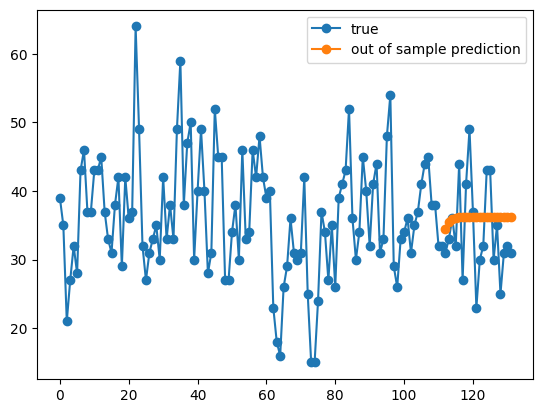

In [205]:
Forecasting_crossValidation( time_series, int(len(time_series)*0.85), optlag = 1)

In [207]:
def Forecasting_CV( time_series, training_size, optlag ):
    """
    Given a pd.Series we train a autoregressive model. 
    The number of training observation is specified by the variable training_size
    """
    train = time_series[:training_size]
    test = time_series[training_size:]
    ar = tsa.AutoReg(train, lags=optlag)
    ar_result = ar.fit()
    #prediction = ar_result.predict(end=len(time_series)-1)[-len(test):]
    prediction = sarima_fit.predict(end=len(time_series)-1)[-len(test):]
    # compute the MAE:
    mae = mean_absolute_error(time_series.values[training_size:], prediction)
    
    return mae

mae_errors = []
for training_size in range(30, len(time_series)-30):
    # choose the optimal lag using AIC (this is a model selection criterion)
    mod = ar_select_order(time_series[:training_size], maxlag=10, ic="aic")
    optlag = 1#max(mod.ar_lags)
    mae_errors.append(Forecasting_CV(time_series, training_size, optlag) )
    
    
print(np.mean(mae_errors))

26.696737149866717


Mean absolute error: 5.671144026576359


2022-09-30    38.299974
2022-10-31    37.113076
2022-11-30    36.591331
2022-12-31    36.361979
2023-01-31    36.261158
2023-02-28    36.216839
2023-03-31    36.197357
2023-04-30    36.188792
2023-05-31    36.185028
2023-06-30    36.183373
2023-07-31    36.182645
2023-08-31    36.182326
2023-09-30    36.182185
2023-10-31    36.182123
2023-11-30    36.182096
2023-12-31    36.182084
2024-01-31    36.182079
2024-02-29    36.182077
2024-03-31    36.182076
2024-04-30    36.182075
2024-05-31    36.182075
2024-06-30    36.182075
2024-07-31    36.182075
2024-08-31    36.182075
2024-09-30    36.182075
2024-10-31    36.182075
2024-11-30    36.182075
2024-12-31    36.182075
2025-01-31    36.182075
2025-02-28    36.182075
2025-03-31    36.182075
2025-04-30    36.182075
2025-05-31    36.182075
2025-06-30    36.182075
2025-07-31    36.182075
2025-08-31    36.182075
2025-09-30    36.182075
2025-10-31    36.182075
2025-11-30    36.182075
2025-12-31    36.182075
Freq: ME, dtype: float64

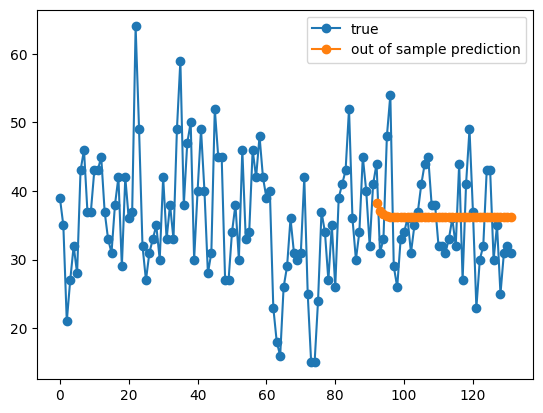

In [209]:
Forecasting_crossValidation( time_series, int(len(time_series)*0.7), optlag = 1)

## EXPONENTIAL SMOOTHING